1. Setup

In [ ]:
import os
import boto3
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# Ladda variabler från .env
load_dotenv()

#  Skapa client med AWS credentials
client = boto3.client(
    "rekognition",
    region_name="us-east-1",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY")
)

# Path till bildmapp
image_folder = "C:\YA BI analyst\Kurser\BI25M AI & IoT\Kunskapskontroll 1\Amazon rekognition"

#Hämta bara bildfiler
image_files = [
    f for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Antal bilder hittade: {len(image_files)}")

<>:19: SyntaxWarning: invalid escape sequence '\Y'
<>:19: SyntaxWarning: invalid escape sequence '\Y'
C:\Users\linus\AppData\Local\Temp\ipykernel_55072\45015811.py:19: SyntaxWarning: invalid escape sequence '\Y'
  image_folder = "C:\YA BI analyst\Kurser\BI25M AI & IoT\Kunskapskontroll 1\Amazon rekognition"


Antal bilder hittade: 50


2. Kör Rekognition på alla bilder

In [2]:
results = []

for file in image_files:
    path = os.path.join(image_folder, file)

    with open(path, "rb") as image:
        response = client.detect_labels(
            Image={"Bytes": image.read()},
            MaxLabels=5
        )

    for label in response["Labels"]:
        results.append({
            "image": file,
            "label": label["Name"],
            "confidence": label["Confidence"]
        })

3. Gör DataFrame

In [3]:
df = pd.DataFrame(results)

df.head()

,image,label,confidence
0,40e1621e-b56b-4611-992d-8d40047dadb7.JPG,Summer,99.998116
1,40e1621e-b56b-4611-992d-8d40047dadb7.JPG,Boat,98.662010
2,40e1621e-b56b-4611-992d-8d40047dadb7.JPG,Adult,96.746979
3,40e1621e-b56b-4611-992d-8d40047dadb7.JPG,Man,96.746979
4,40e1621e-b56b-4611-992d-8d40047dadb7.JPG,Person,96.746979


4. Sammanställning

In [7]:
label_counts = df["label"].value_counts()

label_counts.head(15)

label
Sailboat      20
Boat          17
Yacht         17
Person        15
Portrait      12
Watercraft    12
Waterfront    12
Nature        11
Water         10
Man            7
Outdoors       7
Adult          6
Sea            4
Pants          4
Rock           4
Name: count, dtype: int64

5. Visualisering

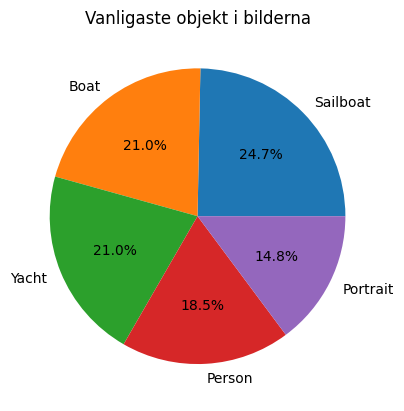

In [5]:
top_labels = label_counts.head(5)

plt.figure()
top_labels.plot.pie(autopct="%1.1f%%")
plt.title("Vanligaste objekt i bilderna")
plt.ylabel("")
plt.show()